<a href="https://colab.research.google.com/github/Harishree2005/Hari-Shree-P/blob/main/Phase1_EDA_Bank_Marketing.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder
plt.style.use('seaborn-v0_8')
sns.set_palette('Set2')

In [2]:
# Load dataset
df=pd.read_csv('bank_marketing_test.csv')
df.head()

,age,job,marital,education,default,housing,loan,contact,month,day_of_week,...,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y
0,56,services,married,high.school,no,no,yes,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
1,41,blue-collar,married,unknown,unknown,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
2,25,services,single,high.school,no,yes,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
3,35,blue-collar,married,basic.6y,no,yes,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
4,46,blue-collar,married,basic.6y,unknown,yes,yes,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no


In [3]:
# Dataset information
print("Shape:",df.shape)
display(df.head())
display(df.info())
display(df.describe())
display(df.describe(include='object'))
print("Columns:",df.columns.tolist())
print("Unique values:")
display(df.nunique())

Shape: (8237, 21)


,age,job,marital,education,default,housing,loan,contact,month,day_of_week,...,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y
0,56,services,married,high.school,no,no,yes,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
1,41,blue-collar,married,unknown,unknown,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
2,25,services,single,high.school,no,yes,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
3,35,blue-collar,married,basic.6y,no,yes,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
4,46,blue-collar,married,basic.6y,unknown,yes,yes,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8237 entries, 0 to 8236
Data columns (total 21 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   age             8237 non-null   int64  
 1   job             8237 non-null   object 
 2   marital         8237 non-null   object 
 3   education       8237 non-null   object 
 4   default         8237 non-null   object 
 5   housing         8237 non-null   object 
 6   loan            8237 non-null   object 
 7   contact         8237 non-null   object 
 8   month           8237 non-null   object 
 9   day_of_week     8237 non-null   object 
 10  duration        8237 non-null   int64  
 11  campaign        8237 non-null   int64  
 12  pdays           8237 non-null   int64  
 13  previous        8237 non-null   int64  
 14  poutcome        8237 non-null   object 
 15  emp.var.rate    8237 non-null   float64
 16  cons.price.idx  8237 non-null   float64
 17  cons.conf.idx   8237 non-null   f

None

,age,duration,campaign,pdays,previous,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed
count,8237.000000,8237.000000,8237.00000,8237.000000,8237.000000,8237.000000,8237.000000,8237.000000,8237.000000,8237.000000
mean,40.116547,256.007648,2.60471,962.228724,0.174335,0.070147,93.577806,-40.545320,3.608206,5166.589790
std,10.465328,259.728737,2.91562,187.533881,0.500565,1.574685,0.582138,4.623626,1.735931,72.470977
min,17.000000,4.000000,1.00000,0.000000,0.000000,-3.400000,92.201000,-50.800000,0.634000,4963.600000
25%,32.000000,101.000000,1.00000,999.000000,0.000000,-1.800000,93.075000,-42.700000,1.344000,5099.100000
50%,38.000000,179.000000,2.00000,999.000000,0.000000,1.100000,93.444000,-41.800000,4.857000,5191.000000
75%,47.000000,316.000000,3.00000,999.000000,0.000000,1.400000,93.994000,-36.400000,4.961000,5228.100000
max,89.000000,4918.000000,43.00000,999.000000,6.000000,1.400000,94.767000,-26.900000,5.000000,5228.100000


,job,marital,education,default,housing,loan,contact,month,day_of_week,poutcome,y
count,8237,8237,8237,8237,8237,8237,8237,8237,8237,8237,8237
unique,12,4,8,2,3,3,2,10,5,3,2
top,admin.,married,university.degree,no,yes,no,cellular,may,mon,nonexistent,no
freq,2115,5041,2477,6480,4262,6822,5215,2751,1743,7113,7309


Columns: ['age', 'job', 'marital', 'education', 'default', 'housing', 'loan', 'contact', 'month', 'day_of_week', 'duration', 'campaign', 'pdays', 'previous', 'poutcome', 'emp.var.rate', 'cons.price.idx', 'cons.conf.idx', 'euribor3m', 'nr.employed', 'y']
Unique values:


,0
age,72
job,12
marital,4
education,8
default,2
housing,3
loan,3
contact,2
month,10
day_of_week,5


In [4]:
# Missing values
print(df.isnull().sum())
for c in df.select_dtypes(include='number').columns:
    df[c]=df[c].fillna(df[c].median())
for c in df.select_dtypes(exclude='number').columns:
    if df[c].isnull().any():
        df[c]=df[c].fillna(df[c].mode()[0])
print("Missing after handling:")
print(df.isnull().sum().sum())

age               0
job               0
marital           0
education         0
default           0
housing           0
loan              0
contact           0
month             0
day_of_week       0
duration          0
campaign          0
pdays             0
previous          0
poutcome          0
emp.var.rate      0
cons.price.idx    0
cons.conf.idx     0
euribor3m         0
nr.employed       0
y                 0
dtype: int64
Missing after handling:
0


In [5]:
# Data Cleaning
print("Duplicates:",df.duplicated().sum())
df=df.drop_duplicates()
for c in df.select_dtypes(include='object').columns:
    df[c]=df[c].astype(str).str.strip().str.lower()
print(df.shape)

Duplicates: 2
(8235, 21)


In [6]:
# Data Transformation (Label Encoding)
df_trans=df.copy()
encoders={}
for c in df_trans.select_dtypes(include='object').columns:
    le=LabelEncoder()
    df_trans[c]=le.fit_transform(df_trans[c])
    encoders[c]=le
df_trans.head()

,age,job,marital,education,default,housing,loan,contact,month,day_of_week,...,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y
0,56,7,1,3,0,0,2,1,6,1,...,1,999,0,1,1.1,93.994,-36.4,4.857,5191.0,0
1,41,1,1,7,1,0,0,1,6,1,...,1,999,0,1,1.1,93.994,-36.4,4.857,5191.0,0
2,25,7,2,3,0,2,0,1,6,1,...,1,999,0,1,1.1,93.994,-36.4,4.857,5191.0,0
3,35,1,1,1,0,2,0,1,6,1,...,1,999,0,1,1.1,93.994,-36.4,4.857,5191.0,0
4,46,1,1,1,1,2,2,1,6,1,...,1,999,0,1,1.1,93.994,-36.4,4.857,5191.0,0


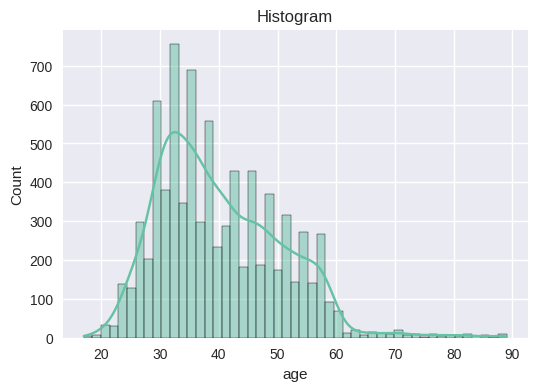

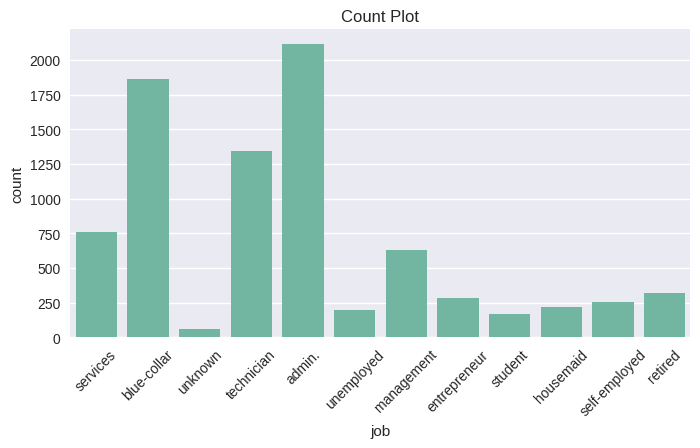

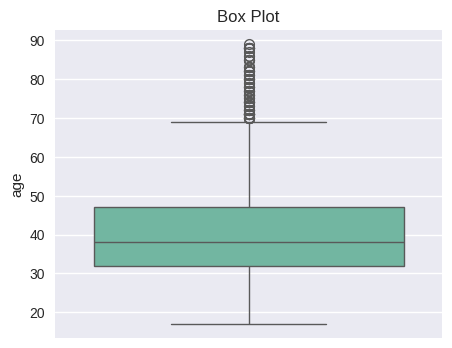

In [7]:
# Univariate Analysis
num=df.select_dtypes(include='number').columns
cat=df.select_dtypes(exclude='number').columns

if len(num)>0:
    plt.figure(figsize=(6,4));sns.histplot(df[num[0]],kde=True);plt.title("Histogram");plt.show()
if len(cat)>0:
    plt.figure(figsize=(8,4));sns.countplot(x=df[cat[0]]);plt.xticks(rotation=45);plt.title("Count Plot");plt.show()
if len(num)>0:
    plt.figure(figsize=(5,4));sns.boxplot(y=df[num[0]]);plt.title("Box Plot");plt.show()

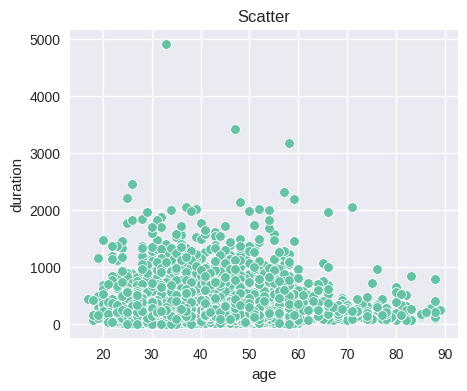

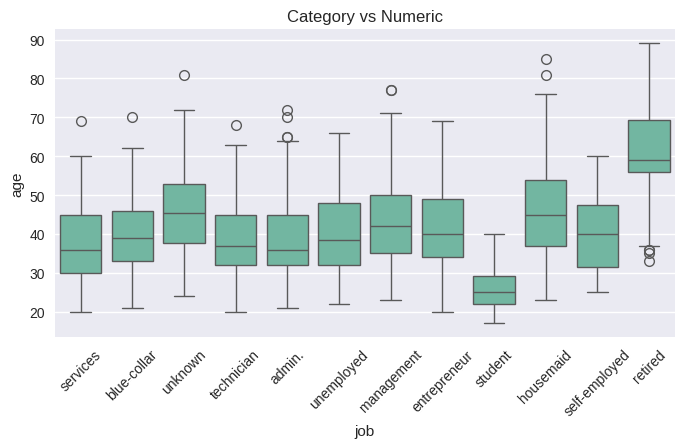

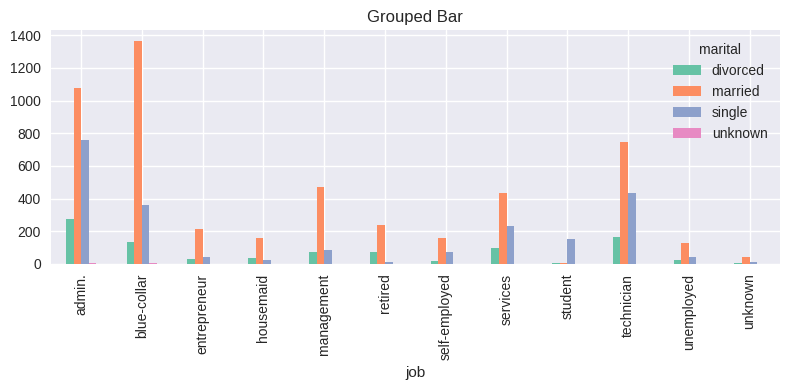

In [8]:
# Bivariate Analysis
if len(num)>=2:
    plt.figure(figsize=(5,4));sns.scatterplot(x=df[num[0]],y=df[num[1]]);plt.title("Scatter");plt.show()
if len(cat)>0 and len(num)>0:
    plt.figure(figsize=(8,4));sns.boxplot(x=df[cat[0]],y=df[num[0]]);plt.xticks(rotation=45);plt.title("Category vs Numeric");plt.show()
if len(cat)>=2:
    ct=pd.crosstab(df[cat[0]],df[cat[1]])
    ct.plot(kind='bar',figsize=(8,4))
    plt.title("Grouped Bar");plt.tight_layout();plt.show()

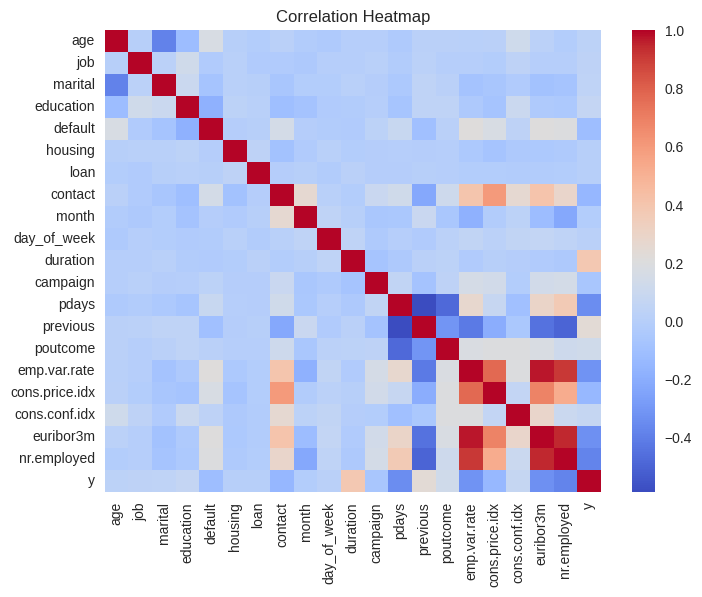

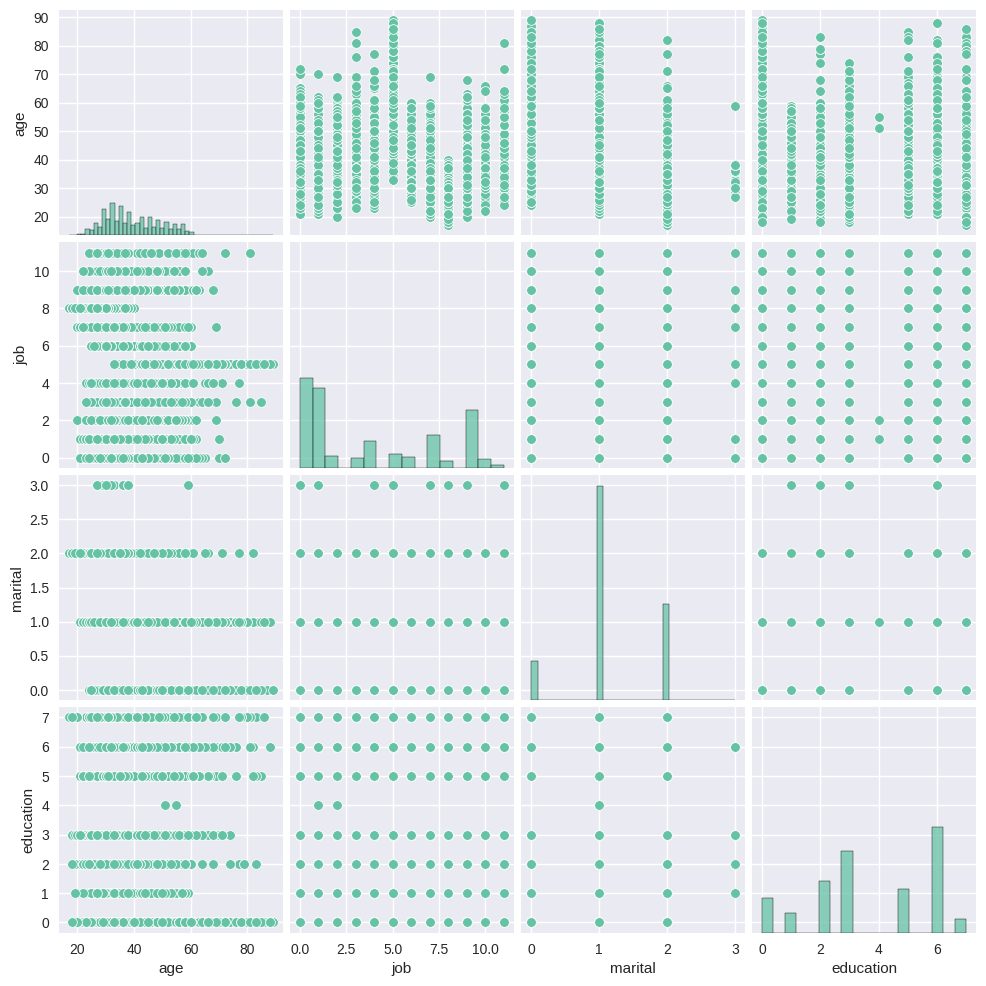

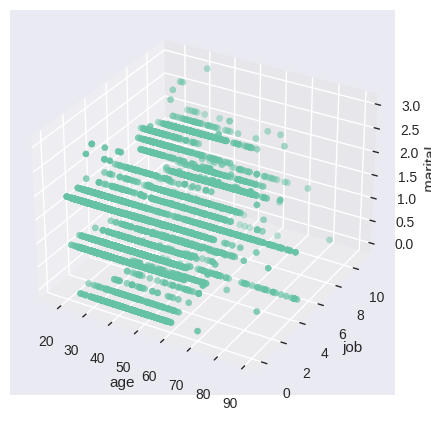

In [9]:
# Multivariate Analysis
plt.figure(figsize=(8,6))
sns.heatmap(df_trans.corr(numeric_only=True),annot=False,cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()

sns.pairplot(df_trans.select_dtypes(include='number').iloc[:,:min(4,len(df_trans.select_dtypes(include='number').columns))])
plt.show()

if len(df_trans.select_dtypes(include='number').columns)>=3:
    from mpl_toolkits.mplot3d import Axes3D
    cols=df_trans.select_dtypes(include='number').columns[:3]
    fig=plt.figure(figsize=(6,5))
    ax=fig.add_subplot(111,projection='3d')
    ax.scatter(df_trans[cols[0]],df_trans[cols[1]],df_trans[cols[2]])
    ax.set_xlabel(cols[0]);ax.set_ylabel(cols[1]);ax.set_zlabel(cols[2])
    plt.show()

In [10]:
# Conclusion
print('Phase 1 completed successfully.')
print('Tasks completed:')
print('- Dataset Loading')
print('- Statistical Analysis')
print('- Missing Value Handling')
print('- Data Cleaning')
print('- Data Transformation')
print('- Univariate Analysis (3)')
print('- Bivariate Analysis (3)')
print('- Multivariate Analysis (3)')

Phase 1 completed successfully.
Tasks completed:
- Dataset Loading
- Statistical Analysis
- Missing Value Handling
- Data Cleaning
- Data Transformation
- Univariate Analysis (3)
- Bivariate Analysis (3)
- Multivariate Analysis (3)
